In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy, csv
import os, sys
import neurokit2 as nk
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))  # Add parent directory to sys.path
from datetime import datetime, timezone
from scipy.signal import resample, butter, filtfilt, find_peaks, hilbert, savgol_filter
from export_AF_Bed import *
from bed_info import *
import warnings
import requests
from urllib.parse import urlparse
warnings.simplefilter(action='ignore', category=FutureWarning)
plt.style.use('default')  # Use default style for better visibility of gridlines

In [93]:
def reconstruct_uniform_signal(timestamps, values, target_fs, fill_method="linear"):
    """
    根据可能存在缺失点的不均匀时间戳，重建 target_fs 的均匀时间轴并补齐数据。

    支持输入:
    - datetime / datetime string
    - 秒级时间戳
    - 毫秒 / 微秒 / 纳秒 Unix 时间戳
    """
    values = np.asarray(values, dtype=float)
    if len(timestamps) != len(values):
        raise ValueError("timestamps 和 values 长度必须一致")

    arr = np.asarray(timestamps)

    # ---------- 1. 转成相对秒 ----------
    if np.issubdtype(arr.dtype, np.number):
        t_num = arr.astype(np.float64)

        # 自动判断单位
        max_abs = np.nanmax(np.abs(t_num))

        if max_abs > 1e17:
            # 纳秒
            t_sec = (t_num - t_num[0]) / 1e9
            base_timestamp = t_num[0]
            unit = "ns"
        elif max_abs > 1e14:
            # 微秒
            t_sec = (t_num - t_num[0]) / 1e6
            base_timestamp = t_num[0]
            unit = "us"
        elif max_abs > 1e11:
            # 毫秒
            t_sec = (t_num - t_num[0]) / 1e3
            base_timestamp = t_num[0]
            unit = "ms"
        else:
            # 秒
            t_sec = t_num - t_num[0]
            base_timestamp = t_num[0]
            unit = "s"

        is_datetime = False

    else:
        ts = pd.to_datetime(timestamps)
        t0 = ts[0]
        t_sec = (ts - t0).total_seconds().to_numpy()
        is_datetime = True
        unit = "datetime"

    # ---------- 2. 排序 ----------
    order = np.argsort(t_sec)
    t_sec = t_sec[order]
    values = values[order]

    # ---------- 3. 映射到理论采样点 ----------
    dt = 1.0 / target_fs
    sample_idx = np.round(t_sec / dt).astype(np.int64)

    # 去重：多个点映射到同一个采样位时取第一个
    sample_idx_unique, first_pos = np.unique(sample_idx, return_index=True)
    values_unique = values[first_pos]

    # ---------- 4. 构造完整均匀序列 ----------
    full_idx = np.arange(sample_idx_unique.min(), sample_idx_unique.max() + 1, dtype=np.int64)
    full_values = np.full(len(full_idx), np.nan, dtype=float)
    full_values[sample_idx_unique - full_idx[0]] = values_unique

    # ---------- 5. 插值补缺失 ----------
    s = pd.Series(full_values)
    if fill_method == "linear":
        full_values = s.interpolate(method="linear", limit_direction="both").to_numpy()
    elif fill_method == "nearest":
        full_values = s.interpolate(method="nearest", limit_direction="both").to_numpy()
    elif fill_method == "ffill":
        full_values = s.ffill().bfill().to_numpy()
    elif fill_method == "none":
        full_values = s.to_numpy()
    else:
        raise ValueError("fill_method 必须是 'linear', 'nearest', 'ffill', 或 'none'")

    # ---------- 6. 生成新的均匀时间戳 ----------
    t_new_sec = full_idx * dt

    if is_datetime:
        new_timestamps = pd.to_datetime(t0) + pd.to_timedelta(t_new_sec, unit="s")
    else:
        if unit == "ns":
            new_timestamps = base_timestamp + np.round(t_new_sec * 1e9).astype(np.int64)
        elif unit == "us":
            new_timestamps = base_timestamp + np.round(t_new_sec * 1e6).astype(np.int64)
        elif unit == "ms":
            new_timestamps = base_timestamp + np.round(t_new_sec * 1e3).astype(np.int64)
        else:
            new_timestamps = base_timestamp + t_new_sec

    return new_timestamps.astype("int64"), full_values
def convert_mindray_n15_csv_to_resampled_npy(
    csv_path: str,
    fs_in: int = 500,
    fs_out: int = 100
):

    ecg_all = []
    ts_all = []

    dt_per_sample_ns = int(1e9 / fs_in)  # 原始采样点间隔

    # -------------------------
    # Step 1: 读原始 CSV
    # -------------------------
    with open(csv_path, "r", encoding="utf-8-sig") as f:
        reader = csv.reader(f)

        for row_idx, row in enumerate(reader):
            if not row:
                continue

            base_time_str = row[0].strip()

            try:
                base_time = pd.to_datetime(base_time_str)
                # print(f"第 {row_idx + 1} 行基准时间: {base_time}，样本数: {len(row) - 1}")
            except Exception as e:
                raise ValueError(
                    f"第 {row_idx + 1} 行时间解析失败: {base_time_str}"
                ) from e

            sample_strs = row[1:]

            if len(sample_strs) != fs_in:
                raise ValueError(
                    f"第 {row_idx + 1} 行样本数不是 {fs_in}，而是 {len(sample_strs)}"
                )

            try:
                samples = np.array(sample_strs, dtype=np.float32)
            except Exception as e:
                raise ValueError(
                    f"第 {row_idx + 1} 行 ECG 数据转换失败"
                ) from e

            base_ns = np.datetime64(base_time.to_datetime64(), "ns")
            offsets = np.arange(fs_in, dtype=np.int64) * dt_per_sample_ns
            timestamps = base_ns + offsets.astype("timedelta64[ns]")

            ecg_all.append(samples)
            ts_all.append(timestamps)

    ecg = np.concatenate(ecg_all, axis=0)  # (N,)
    timestamps = np.concatenate(ts_all, axis=0)  # datetime64[ns], (N,)
    # 检查时间戳有没有跨天，有的话把日期加上：
    time_diff = np.diff(timestamps).astype("timedelta64[ns]").astype(np.int64)
    if np.any(time_diff < 0):
        day_ns = np.timedelta64(1, "D").astype("timedelta64[ns]").astype(np.int64)
        for i in range(1, len(timestamps)):
            if time_diff[i - 1] < 0:
                timestamps[i:] += day_ns
    print(pd.to_datetime(timestamps[0]), pd.to_datetime(timestamps[-1]), len(ecg))
    timestamps_resampled_ns, ecg_resampled = reconstruct_uniform_signal(timestamps, ecg, target_fs=fs_out)  # 测试函数是否正常运行
    return ecg_resampled, timestamps_resampled_ns
    # return ecg, timestamps


def clean_resampled_ecg_npy(
    data: np.ndarray,
    fs: int = 100,
    method: str = "neurokit"
):
    """
    读取 [timestamp_ns, ecg] 的 stacked npy，
    用 neurokit2 对 ECG 做去噪/清洗，并进一步去趋势，
    最后保存成新的 stacked npy。

    Parameters
    ----------
    input_path : str
        输入的 stacked npy 文件路径
    output_path : str
        输出的 cleaned stacked npy 文件路径
    fs : int
        采样率，默认 100 Hz
    method : str
        nk.ecg_clean 的方法，默认 "neurokit"
        可选如: "neurokit", "biosppy", "pantompkins1985", "hamilton2002", ...

    Returns
    -------
    cleaned_stacked : np.ndarray
        shape = (N, 2)
        [:, 0] = timestamp_ns
        [:, 1] = cleaned_ecg
    """

    # -------------------------
    # Step 1: 读取数据
    # -------------------------

    if data.ndim != 2 or data.shape[1] != 2:
        raise ValueError(f"输入数据 shape 应为 (N, 2)，当前为 {data.shape}")

    timestamp_ns = data[:, 0].astype(np.int64)
    ecg = data[:, 1].astype(np.float64)

    # -------------------------
    # Step 2: ECG 清洗（滤波 / 去噪）
    # -------------------------
    ecg_cleaned = nk.ecg_clean(ecg, sampling_rate=fs, method=method)

    # -------------------------
    # Step 3: 去趋势
    # order=1 常用于移除缓慢漂移
    # regularization 更平滑一些，也可换成 "polynomial"
    # -------------------------
    ecg_detrended = nk.signal_detrend(
        ecg_cleaned,
        method="polynomial",
        order=1
    )

    # -------------------------
    # Step 4: stack 保存
    # -------------------------
    cleaned_stacked = np.column_stack([
        timestamp_ns.astype(np.float64),
        ecg_detrended.astype(np.float64)
    ])

    return cleaned_stacked
def find_idx(target_time, timestamps, time_zone="UTC", exact=False):
    # Parse timestamps as timezone-aware UTC for reliable matching.
    ts = pd.to_datetime(timestamps, utc=True)
    
    # Interpret target_time in the provided timezone, then convert to UTC.
    target = pd.to_datetime(target_time)
    if target.tzinfo is None:
        target = target.tz_localize(time_zone)
    else:
        target = target.tz_convert(time_zone)
    target = target.tz_convert("UTC")
    
    if exact:
        matches = (ts == target)
        if matches.any():
            return matches.argmax()   # 第一个匹配位置
        else:
            raise ValueError(f"target_time {target} 不在 timestamps 中")
    else:
        # 找最近的时间点
        diff = abs(ts - target)
        return diff.argmin()
    

def norm_ecg(ECG):
    ECG = (ECG - np.min(ECG)) / (np.max(ECG) - np.min(ECG))
    return ECG
def timestamp_to_seconds(timestamps):
    # Convert ISO 8601 timestamps to seconds since the first timestamp
    base_time = pd.to_datetime(timestamps[0])
    seconds = [(pd.to_datetime(ts) - base_time).total_seconds()
               for ts in timestamps]
    return np.array(seconds)
def butter_bandpass(x, fs, lo=0.5, hi=30.0, order=3):
    b, a = butter(order, [lo, hi], btype='band', fs=fs)
    return filtfilt(b, a, x)

def lowpass(x, fs, fc=0.6, order=3):
    b, a = butter(order, fc, btype='low', fs=fs)
    return filtfilt(b, a, x)

def _butter_bandpass(low, high, fs, order=3):
    nyq = 0.5 * fs
    b, a = butter(order, [low/nyq, high/nyq], btype="band")
    return b, a
def extract_hilbert_envelope_and_remove(
    x: np.ndarray,
    smooth_win: int | None = None,
    smooth_poly: int = 3,
    remove_method: str = "divide",
    eps: float = 1e-8,
):
    """
    计算 Hilbert 包络，并从原始信号中去除包络。

    参数
    ----
    x : 1D numpy array，信号取值在 [0, 1] 或任意实数范围均可
    smooth_win : 可选，对包络做 Savitzky–Golay 平滑的窗口长度(奇数)。None 表示不平滑
    smooth_poly : Savitzky–Golay 的多项式阶数（通常 2 或 3 即可）
    remove_method : "divide" 或 "subtract"
        - "divide": 按包络幅度进行幅度解调 y = x / (env + eps)
        - "subtract": 直接相减 y = x - env
    eps : 防止除零的微小常数

    返回
    ----
    env : np.ndarray, Hilbert 包络（可选已平滑）
    y   : np.ndarray, 去除包络后的信号
    """
    x = butter_bandpass(x, 100)
    x= np.pad(x, (20,0), 'edge')
    x = np.asarray(x, dtype=float).ravel()

    # 1) Hilbert 分析信号与包络
    analytic = hilbert(x)
    env = np.abs(analytic)

    # 2) 可选：对包络做平滑（建议 smooth_win 为奇数且 >= 5）
    if smooth_win is not None and smooth_win >= 5 and smooth_win % 2 == 1:
        # 若窗口过小或长度超过信号，会自动调整到合适范围
        win = min(smooth_win, len(env) - (1 - len(env) % 2))
        win = max(win, 5 if (5 <= len(env)) else (len(env) | 1))  # 保证奇数
        if win >= 5 and win % 2 == 1 and win <= len(env):
            env = savgol_filter(env, window_length=win, polyorder=min(smooth_poly, win - 2))

    # 3) 去除包络
    remove_method = remove_method.lower()
    if remove_method == "divide":
        # 常用于幅度解调：保留载波/细节，移除慢变幅度
        y = x / (env + eps)
        # 可选：把结果移回零均值或原范围（按需再处理）
        y[20:] = (y[20:] - np.mean(y[20:]))+np.mean(x[20:])  # 如果你希望零均值，可取消注释
    elif remove_method == "subtract":
        # 直接减去包络，得到高频残差（更像去慢趋势）
        y = x - env
    else:
        raise ValueError("remove_method 只能是 'divide' 或 'subtract'。")
    temp = y[20:]
    # rescale to original amplitude
    y[20:] = (temp - np.min(temp)) / (np.max(temp) - np.min(temp)) * (np.max(x[20:]) - np.min(x[20:])) + np.min(x[20:])
    return env[20:], y[20:]
def resample_signal(x, original_fs, target_fs):
    num_samples = int(len(x) * target_fs / original_fs)
    return resample(x, num_samples)


def resample_with_timestamps(timestamps, x, target_fs):
    """
    根据原始时间戳和信号值，重采样到目标采样率

    Parameters
    ----------
    timestamps : array-like
        可被 pandas.to_datetime 解析的时间戳序列
    x : array-like
        对应信号值
    target_fs : float
        目标采样率，例如 100 Hz

    Returns
    -------
    new_timestamps : pd.DatetimeIndex
        重采样后的时间戳
    x_new : np.ndarray
        重采样后的信号
    """
    timestamps = pd.to_datetime(timestamps)
    x = np.asarray(x)

    if len(timestamps) != len(x):
        raise ValueError("timestamps 和 x 长度必须一致")
    sort_idx = np.argsort(timestamps)
    timestamps = timestamps[sort_idx]
    x = x[sort_idx]
    # 转成相对秒
    t0 = timestamps[0]
    t_sec = (timestamps - t0).total_seconds().to_numpy()

    # 生成新的等间隔时间轴
    dt = 1.0 / target_fs
    t_new_sec = np.arange(t_sec[0], t_sec[-1], dt)

    # 线性插值
    x_new = np.interp(t_new_sec, t_sec, x)
    # print(x_new)
    # 生成新的时间戳
    new_timestamps = t0 + pd.to_timedelta(t_new_sec, unit="s")

    return new_timestamps.astype("int64"), x_new


In [94]:
root_path = './data/'
target_path = './invasive_BP/'
info_table = '../Invasive_BP/invasive_bp.xlsx'
info = pd.read_excel(info_table)
fs = 100
info.keys()

Index(['患者序号', '采集时间', 'Unnamed: 2', '床位号', '枕头设备号', 'beddot设备号', '性别', '年龄',
       '身高（cm）', '体重（kg）', '腹围（cm）', '监护仪数据链接', 'Unnamed: 12', 'Unnamed: 13',
       '枕头数据链接', '备注', 'grafana链接', 'Unnamed: 17'],
      dtype='object')

In [95]:
def new_struct():
    data_struct = {
        "Info" : {
            "Subject" : None, # -1 means chirp wave, 0-9 means real human subjects
            "Bed_ID" : None,
            "Height" : None,
            "Weight" : None,
            "Abdominal_Girth" : None,
            "Mattress_Thickness" : None, # can be 5, 10 cm
            "Other_comment" : 'fs = 100 for signals, fs=1 for discrete readings',
        },
        # Vital signs
        "BSG" : None, # [BSG_x, BSG_y, BSG_z]
        "ECG" : None,
        "ABP" : None,
        "HR" : None,
        "RR" : None,
        "DBP" : None,
        "SBP" : None,
        "MAP" : None,
        "Timestamp" : None,
    }
    return data_struct


### Info. of the current trial

In [96]:
line = 17
# line = 5
cur_struct = new_struct()
# selected_bed = bed_AF_ID_30_up
cur_struct['Info']['Subject'] = info['患者序号'][line]
cur_struct['Info']['Bed_ID'] = info['床位号'][line][:-1]
cur_struct['Info']['Height'] = info['身高（cm）'][line]
cur_struct['Info']['Weight'] = info['体重（kg）'][line]
cur_struct['Info']['Abdominal_Girth'] = info['腹围（cm）'][line]
# cur_struct['Info']['Mattress_Thickness'] = info['床垫厚度'][line]


### Read BedDot data

In [97]:
start_time_str = f"{str(info['采集时间'][line])[:10]} {info['Unnamed: 2'][line]}"
start_time = pd.to_datetime(start_time_str)
duration = 2 * 60 * 60  # 2 hours
# duration = 100
end_time = start_time + pd.Timedelta(seconds=duration)
print(start_time, end_time)

2026-01-30 23:50:00 2026-01-31 01:50:00


In [98]:
cur_struct['Info']['Bed_ID']
bed_dot_id = info['beddot设备号'][line]
selected_bed = None
for bed in BED_MAP.values():
    if (f"bed_{cur_struct['Info']['Bed_ID']}_ID_{bed_dot_id}".lower() == bed['SID'].lower()):
        selected_bed = bed
        break
if selected_bed is None:
    print(f"No matched bed found: Bed_ID={cur_struct['Info']['Bed_ID']}, Beddot ID={bed_dot_id}")
else: 
    cur_struct['Info']['Mattress_Thickness'] = selected_bed['Mattress Thickness']
    output_filename = f"../data/sub_{cur_struct['Info']['Subject']}_{selected_bed['SID']}.npy"
output_filename

'../data/sub_17_bed_07_ID_7.npy'

In [99]:
# cost about 3 minutes to process 2 hours BSG data at 100 Hz sampling rate
start_time_str = f'{start_time}'
if os.path.exists(output_filename):
# if False:
    print(f"File already exists: {output_filename}, skipping processing.")
else:
    start_time_str = str(start_time).replace(" ", "T")
    end_time_str = str(end_time).replace(" ", "T")
    # try:
    bsg_3axis = get_bsg_3axis_readings(
    bed_address_info=selected_bed,
    start_time_str=start_time_str,
    end_time_str=end_time_str,
    sampling_rate=100,
    compression_factor=1,
    )

    # Save as [X, Y, Z] stacked array with shape: (3, num_points)
    stacked_3axis = np.stack(
    [bsg_3axis["x"], bsg_3axis["y"], bsg_3axis["z"]], axis=0)
    payload = {
    "data": stacked_3axis,
    "timestamps": bsg_3axis["timestamps"],
    }
    np.save(output_filename, payload)
    print(
    f"BSG payload saved to {output_filename}, data shape: {stacked_3axis.shape}, timestamps shape: {bsg_3axis['timestamps'].shape}")
    print("Done.")


File already exists: ../data/sub_17_bed_07_ID_7.npy, skipping processing.


In [100]:
bsg_data = np.load(output_filename, allow_pickle=True).item()
cur_struct['BSG'] = bsg_data['data']
cur_struct['Timestamp'] = bsg_data['timestamps'] + 8 * 3600 * 1e9  # 转成北京时间（东八区）
print(len(cur_struct['Timestamp']), pd.to_datetime(cur_struct['Timestamp'][0]))

720001 2026-01-30 23:50:00


### Process Monitor Output

In [101]:
root = '../data/invasive_mindary'
files = os.listdir(root)
for file in files:
    if file.startswith('.'):
        continue
    id = int(file)
    if id == cur_struct['Info']['Subject']:
        print(f"Found file for subject {id}: {os.path.join(root, file)}")
        break
# go through the files in the subject folder and find the ECG file
subject_folder = os.path.join(root, f"{file}")
ecg_file, abp_file, param_file = None, None, None
# walk through the subject folder to find the ECG file
for dirpath, dirnames, filenames in os.walk(subject_folder):
    for filename in filenames:
        if filename.startswith('ECG_II') and filename.endswith('.csv') and not filename.startswith('ECG_III'):
            ecg_file = os.path.join(dirpath, filename)
            print(f"Found ECG file: {ecg_file}")
            # break
        if filename.startswith('Art') and filename.endswith('.csv'):
            abp_file = os.path.join(dirpath, filename)
            print(f"Found ABP file: {abp_file}")
            # break
        if filename.startswith('ParameterData') and filename.endswith('.csv'):
            param_file = os.path.join(dirpath, filename)
            print(f"Found Parameter file: {param_file}")
            # break

Found file for subject 17: ../data/invasive_mindary/17
Found Parameter file: ../data/invasive_mindary/17/ParameterData/ParameterData-1S-20260130017.csv
Found ABP file: ../data/invasive_mindary/17/WaveformData/Art-20260130017.csv
Found ECG file: ../data/invasive_mindary/17/WaveformData/ECG_II-20260130017.csv


In [102]:
fs_ecg, fs_abp = 500, 128
ABP, abp_time = convert_mindray_n15_csv_to_resampled_npy(abp_file, fs_in=fs_abp, fs_out=100)
if ecg_file is not None:
    ecg, date_time = convert_mindray_n15_csv_to_resampled_npy(ecg_file, fs_in=fs_ecg, fs_out=100)
else:
    print("No ECG file found, filling with -1.")
    ecg = -np.ones_like(ABP, dtype=np.float32)  # 如果没有 ECG 文件，填充 -1
    date_time = abp_time

# ecg_cleaned = clean_resampled_ecg_npy(data=np.column_stack([date_time.astype(np.float64), ecg.astype(np.float64)]), fs=100, method="neurokit")


2026-04-13 23:50:01 2026-04-14 01:50:00.992187500 921600
2026-04-13 23:50:01 2026-04-14 01:50:00.998000 3600000


In [103]:
pd.to_datetime(date_time)

DatetimeIndex([       '2026-04-13 23:50:01', '2026-04-13 23:50:01.010000',
               '2026-04-13 23:50:01.020000', '2026-04-13 23:50:01.030000',
               '2026-04-13 23:50:01.040000', '2026-04-13 23:50:01.050000',
               '2026-04-13 23:50:01.060000', '2026-04-13 23:50:01.070000',
               '2026-04-13 23:50:01.080000', '2026-04-13 23:50:01.090000',
               ...
               '2026-04-14 01:50:00.910000', '2026-04-14 01:50:00.920000',
               '2026-04-14 01:50:00.930000', '2026-04-14 01:50:00.940000',
               '2026-04-14 01:50:00.950000', '2026-04-14 01:50:00.960000',
               '2026-04-14 01:50:00.970000', '2026-04-14 01:50:00.980000',
               '2026-04-14 01:50:00.990000',        '2026-04-14 01:50:01'],
              dtype='datetime64[ns]', length=720001, freq=None)

In [104]:
# split ecg_file name between - and .csv
ecg_file_name = abp_file.split('-')[-1].split('.')[0]  # 假设 ecg_file 是完整的文件路径
year, month, day = int(ecg_file_name[0:4]), int(ecg_file_name[4:6]), int(ecg_file_name[6:8])
# turn to timestamp
temp_stamp = pd.Timestamp(year=year, month=month, day=day)

# get today's date, only to day
today = pd.to_datetime("today").normalize()
dat_diff = today - temp_stamp
date_time = date_time.astype('datetime64[ns]') - dat_diff
abp_time = abp_time.astype('datetime64[ns]') - dat_diff
pd.to_datetime(date_time[0]), pd.to_datetime(cur_struct['Timestamp'][0]), pd.to_datetime(abp_time[0])

(Timestamp('2026-01-30 23:50:01'),
 Timestamp('2026-01-30 23:50:00'),
 Timestamp('2026-01-30 23:50:01'))

In [105]:
start_bsg, start_ecg, start_abp = (cur_struct['Timestamp'].astype('datetime64[ns]'))[0], date_time[0], abp_time[0]
end_bsg, end_ecg, end_abp = (cur_struct['Timestamp'].astype('datetime64[ns]'))[-1], date_time[-1], abp_time[-1]
start_final = np.max([start_bsg, start_ecg, start_abp])
end_final = np.min([end_bsg, end_ecg, end_abp])
print(f"Final aligned time range: {pd.to_datetime(start_final)} to {pd.to_datetime(end_final)}")

Final aligned time range: 2026-01-30 23:50:01 to 2026-01-31 01:50:00


In [106]:
pd.to_datetime(end_abp)

Timestamp('2026-01-31 01:50:00.990000')

In [107]:
idx_start_bsg = find_idx(pd.to_datetime(start_final), cur_struct['Timestamp'], exact=True)
idx_end_bsg = find_idx(pd.to_datetime(end_final), cur_struct['Timestamp'], exact=False)
idx_start_ecg = find_idx(pd.to_datetime(start_final), date_time, exact=True)
idx_end_ecg = find_idx(pd.to_datetime(end_final), date_time, exact=True)
idx_start_abp = find_idx(pd.to_datetime(start_final), abp_time, exact=True)
idx_end_abp = find_idx(pd.to_datetime(end_final), abp_time, exact=True)
cur_struct['ECG'] = ecg[idx_start_ecg:idx_end_ecg]
cur_struct['ABP'] = ABP[idx_start_abp:idx_end_abp]
cur_struct['Timestamp'] = cur_struct['Timestamp'][idx_start_bsg:idx_end_bsg]
cur_struct['BSG'] = cur_struct['BSG'][:, idx_start_bsg:idx_end_bsg]
if len(cur_struct['ECG']) != len(cur_struct['ABP']) or len(cur_struct['ECG']) != len(cur_struct['Timestamp']):
    print(f"Warning: Length mismatch after alignment! ECG: {len(cur_struct['ECG'])}, ABP: {len(cur_struct['ABP'])}, Timestamp: {len(cur_struct['Timestamp'])}")
print(len(cur_struct['ECG']), len(cur_struct['ABP']), len(cur_struct['Timestamp']), cur_struct['BSG'].shape)
print(idx_start_bsg, idx_end_bsg, idx_start_ecg, idx_end_ecg, idx_start_abp, idx_end_abp)

719900 719900 719900 (3, 719900)
100 720000 0 719900 0 719900


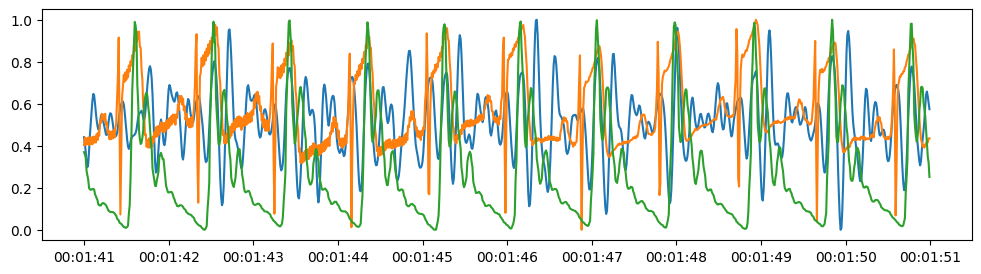

In [108]:
plt.figure(figsize=(12, 3))
t = pd.to_datetime(cur_struct['Timestamp'])
start = 200000-700
start = 70000
end = start+1000
plt.plot(t[start:end], norm_ecg(cur_struct['BSG'][1, start:end]), label='BSG Y-axis')
# ecg
plt.plot(t[start:end],norm_ecg(cur_struct['ECG'][start:end]), label='ECG')
plt.plot(t[start:end],norm_ecg(cur_struct['ABP'][start:end]), label='ABP')

In [109]:
# read from csv
param_data = pd.read_csv(param_file)
print(param_data.columns)

Index(['Time', ' HR(bpm)', ' SpO2(%)', ' PI(%)', ' RR(rpm)', ' PR(bpm)',
       ' Art-S(mmHg)', ' Art-D(mmHg)', ' Art-M(mmHg)', ' PVCs(/min)',
       ' Pauses(/min)', ' VPBs(/min)', ' Couplets(/min)',
       ' Missed beats(/min)', ' R on Ts(/min)'],
      dtype='object')


In [110]:
timestamp_param = param_data['Time'].apply(lambda x: pd.to_datetime(x.strip()) - dat_diff)
HR = param_data[' HR(bpm)'].replace('--', -1).astype(float).to_numpy()
RR = param_data[' RR(rpm)'].replace('--', -1).astype(float).to_numpy()
DBP = param_data[' Art-D(mmHg)'].replace('--', -1).astype(float).to_numpy()
SBP = param_data[' Art-S(mmHg)'].replace('--', -1).astype(float).to_numpy()
MAP = param_data[' Art-M(mmHg)'].replace('--', -1).astype(float).to_numpy()
start_index = find_idx(pd.to_datetime(start_final), timestamp_param, exact=True)
end_index = find_idx(pd.to_datetime(end_final), timestamp_param, exact=False)
print(f"Parameter data aligned time range: {timestamp_param[start_index]} to {timestamp_param[end_index]}")

Parameter data aligned time range: 2026-01-30 23:50:01 to 2026-01-30 23:59:59


In [111]:
cur_struct['HR'] = HR[start_index:end_index]
cur_struct['RR'] = RR[start_index:end_index]
cur_struct['DBP'] = DBP[start_index:end_index]
cur_struct['SBP'] = SBP[start_index:end_index]
cur_struct['MAP'] = MAP[start_index:end_index]

In [112]:
cur_struct

{'Info': {'Subject': 17,
  'Bed_ID': '07',
  'Height': 175,
  'Weight': 71.0,
  'Abdominal_Girth': 94.0,
  'Mattress_Thickness': 5.5,
  'Other_comment': 'fs = 100 for signals, fs=1 for discrete readings'},
 'BSG': array([[  30361.,   28212.,   20116., ...,   56933.,   75621.,   70513.],
        [ -25449.,  -44852.,  -54537., ...,  107046.,  117509.,  121117.],
        [  25342.,   32139.,   20001., ...,  -88218., -108406., -123335.]]),
 'ECG': array([ 308.,  456.,  240., ...,  -40., -116., -160.]),
 'ABP': array([ 845.,  838.,  833., ..., 1066., 1053., 1107.]),
 'HR': array([66., 67., 67., 67., 67., 67., 67., 67., 67., 67., 67., 67., 67.,
        67., 67., 67., 67., 67., 68., 68., 68., 68., 68., 68., 68., 68.,
        68., 67., 67., 67., 67., 67., 67., 67., 67., 68., 68., 68., 68.,
        69., 69., 69., 69., 68., 68., 68., 68., 68., 68., 68., 69., 69.,
        69., 69., 69., 69., 72., 74., 75., 75., 75., 74., 74., 74., 74.,
        73., 69., 69., 69., 69., 69., 70., 70., 70., 70., 70.

In [113]:
# dsfsd

In [114]:
np.save(f'../{target_path}/sub_{cur_struct["Info"]["Subject"]}_raw.npy', cur_struct)

In [115]:
# print current time and sub
print(f"Finished processing subject {cur_struct['Info']['Subject']} at {datetime.now(timezone.utc).astimezone().isoformat()}")

Finished processing subject 17 at 2026-04-13T17:19:17.147571+08:00
